<a href="https://colab.research.google.com/github/opaiot/ia-otimizacao-iot-industrias-negocios-public/blob/feature%2Fsync-colab/adds/regressao_linear_consumo_energia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Bem-vindos ao OpAIoT 🚀

In [ ]:
#primeiro código
print("Olá, Mundo!")

Olá, OpAioT!


# Regressão Linear para Previsão de Consumo de Energia em Edifícios

- https://www.kaggle.com/datasets/elikplim/eergy-efficiency-dataset/
- https://archive.ics.uci.edu/dataset/242/energy+efficiency

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Carregamento dos dados

In [ ]:
df=pd.read_csv("/content/ENB2012_data.csv")
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [ ]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


In [ ]:
print("Valores nulos:n",df.isnull().sum())
print("Valores duplicados:n",df.duplicated().sum())

Valores nulos:n X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
X7    0
X8    0
Y1    0
Y2    0
dtype: int64
Valores duplicados:n 0


# Limpeza dos dados

In [ ]:
df = df.dropna()
df = df.drop_duplicates()

#Visualização dos dados

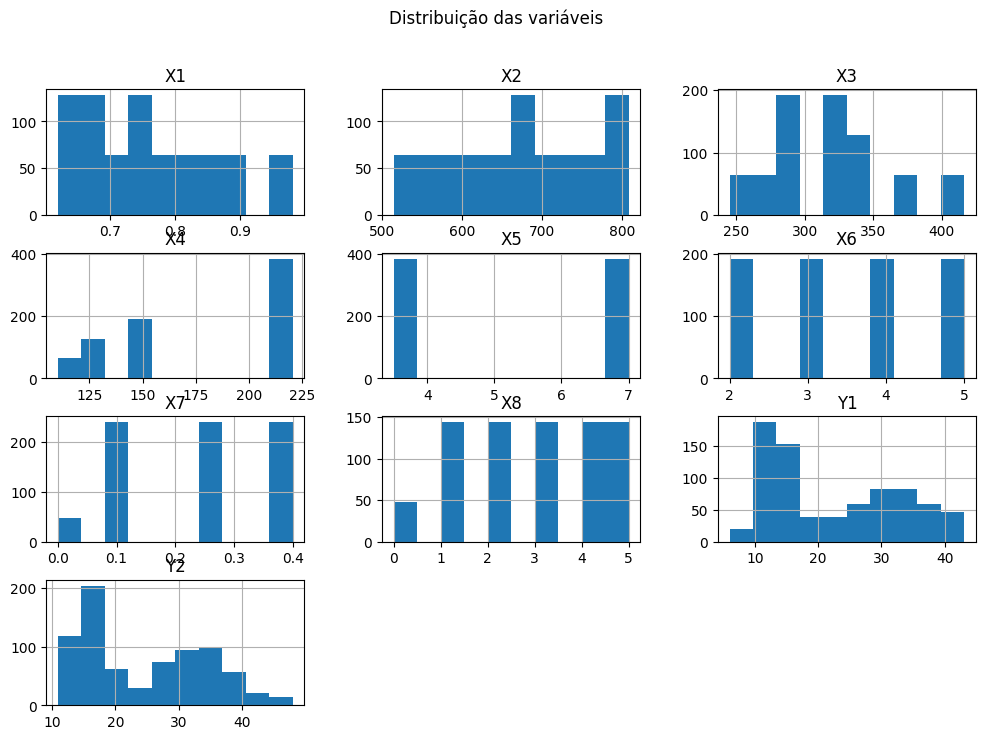

In [ ]:
df.hist(figsize=(12,8))
plt.suptitle("Distribuição das variáveis")
plt.show()

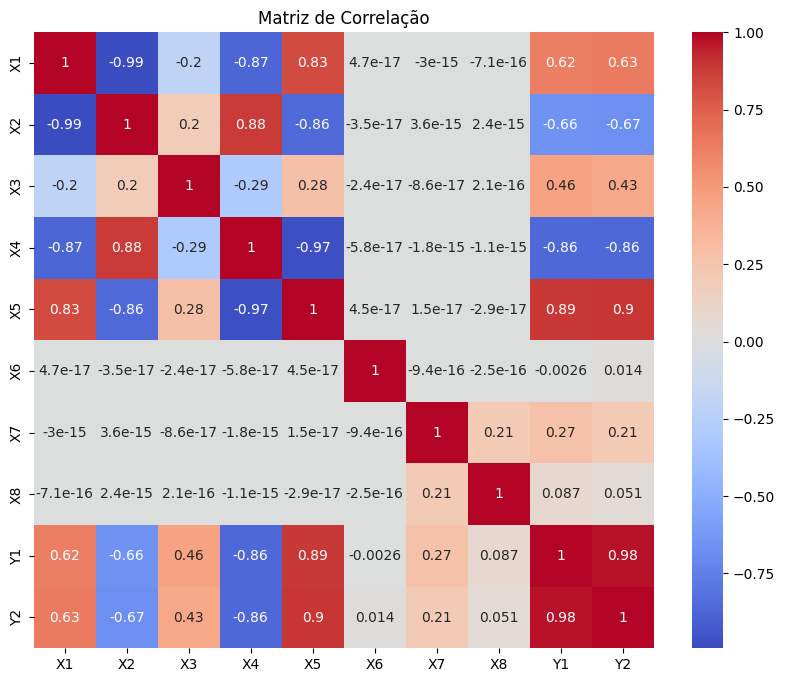

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.show()

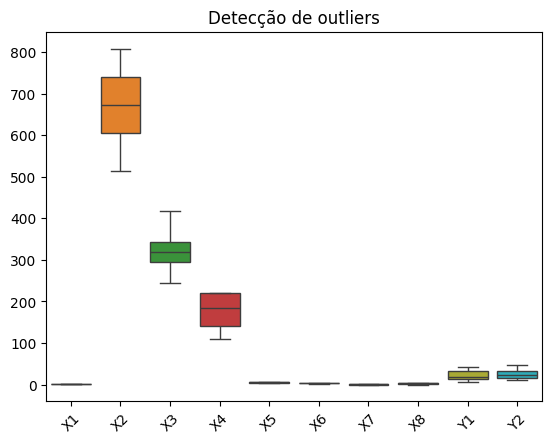

In [ ]:
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Detecção de outliers")
plt.show()

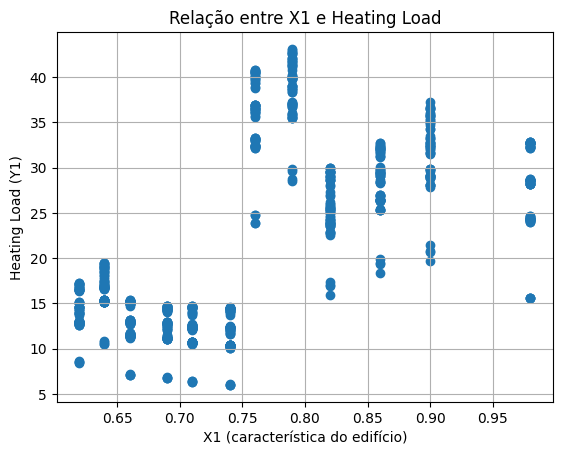

In [ ]:
plt.scatter(df["X1"], df["Y1"])
plt.xlabel("X1 (característica do edifício)")
plt.ylabel("Heating Load (Y1)")
plt.title("Relação entre X1 e Heating Load")
plt.grid()
plt.show()


# Modelagem

In [ ]:
X = df.drop(["Y1", "Y2"], axis=1)
y = df["Y1"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

#Previsão

In [ ]:
y_pred = model.predict(X_test)

# Avaliação do modelo

In [ ]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2:", r2)
print("MSE:", mse)

R2: 0.912184095154691
MSE: 9.153187855202754


In [ ]:
print(f"O modelo explica aproximadamente {r2*100:.1f}% da variação dos dados.")
print("Coeficientes do modelo:", model.coef_)

O modelo explica aproximadamente 91.2% da variação dos dados.
Coeficientes do modelo: [-6.18733542e+01 -6.01052714e-02  3.75534653e-02 -4.88293684e-02
  4.12366921e+00 -3.24391125e-02  2.01431925e+01  2.11102833e-01]


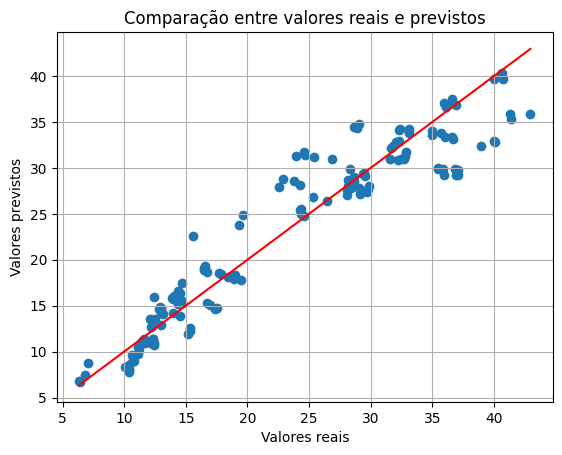

In [ ]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.xlabel("Valores reais")
plt.ylabel("Valores previstos")
plt.title("Comparação entre valores reais e previstos")
plt.grid()
plt.show()

In [ ]:
import pandas  as pd
df = pd.DataFrame({
    'nome': ['João', 'Ana', 'João'],
    'idade': [25, 30, 25]
})

print(df.duplicated())

0    False
1    False
2     True
dtype: bool


In [ ]:
df[df.duplicated()]

,nome,idade
2,João,25


In [ ]:
df[df.duplicated(keep=False)]

,nome,idade
0,João,25
2,João,25


In [ ]:
df.duplicated(subset=['nome'])

,0
0,False
1,False
2,True
